# The Klinger Volume Oscillator — a quantitative teardown 🔬
### KVO(34,55,13) long/flat & long/short on SPY · net Sharpe vs buy-and-hold (excess-vs-excess) · HAC *t* on the daily difference · a block-permutation placebo · head-to-head vs SMA & MACD · a synthetic volume-leads-price control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_price%3F: Busted](https://img.shields.io/badge/Leads_price%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Klinger's oscillator is sold as a **leading** signal because it reads volume. We test that literally: turn it into a daily timing rule, race it **net of costs, excess-of-cash** against buy-and-hold and the obvious simpler trend rules, and ask whether *when* it is long carries any information at all.

> ⚠️ **Data note.** SPY daily OHLCV (yfinance, auto-adjusted = **total-return** proxy), 2005-01-03→2026-05-29, **21 years**, as-of **2026-05-31** (the partial current month is dropped). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from klinger_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY")
    SPY = SPY[SPY.index <= ASOF]      # drop the partial current month (house rule)
else:
    SPY = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)),
      "| last:", (None if SPY is None else SPY.index[-1].date()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_days': 5385, 'fp': '63d0db58b0a8', 'k_sharpe': 0.382, 'hold_sharpe': 0.645, 'sma_sharpe': 0.776, 'macd_sharpe': 0.548, 'k_cagr': 0.037, 'hold_cagr': 0.11, 'sma_cagr': 0.085, 'k_mdd': -0.489, 'hold_mdd': -0.552, 'sma_mdd': -0.209, 'k_tim': 0.53, 'k_turn': 21.9, 't_vs_hold': -2.87, 't_vs_sma': -1.78, 't_vs_macd': -0.94, 'placebo_p': 0.669, 'placebo_median': 0.444, 'variants': [('KVO>0 long/flat', 0.382, -2.87), ('KVO>0 long/short', -0.203, -2.92), ('KVO>signal long/flat', 0.138, -4.09), ('KVO>signal long/short', -0.481, -4.14)], 'costs': [(0.0, 0.402, -2.8), (1.0, 0.382, -2.87), (2.0, 0.363, -2.95), (5.0, 0.304, -3.18)], 'panel': [('SPY', 0.382, 0.645, -2.87), ('QQQ', 0.652, 0.778, -2.65), ('IWM', 0.393, 0.47, -1.43), ('DIA', 0.394, 0.617, -2.48), ('EEM', 0.203, 0.4, -2.07), ('GLD', 0.317, 0.677, -2.96)], 'syn': [(0.0, -0.633, -0.355, -0.51, 0.981), (3.0, 5.613, 0.439, 8.21, 0.0)]}


real SPY cache present: True | days: 5385 | last: 2026-05-29


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Klinger long/flat net Sharpe **0.38** vs buy-and-hold **0.65**; HAC *t* of the daily difference = **-2.87** (significantly *worse*, not better). |
| **Tradability** | `MIRAGE` | Loses the race at every cost level (~22 round-trips/yr), and beaten by a one-line 200d SMA (**0.78**, *t* = -1.78). Nothing to deploy. |
| **Volume leads price?** | `BUSTED` | A block-shuffled random schedule with the same time-in-market beats Klinger's timing **p = 0.67** of the time (median random Sharpe **0.44** > Klinger's **0.38**). |

> 💡 In plain words: a *leading* indicator should beat buy-and-hold, or at least beat a coin. Klinger does neither — it is a lagging moving-average of volume wearing a leading-indicator label.

## 1 · The claim, steelmanned

Klinger's **Volume Force** weights each day's volume by its range position and trend:

$$\mathrm{VF}_t = V_t \cdot \left|\,2\frac{dm_t}{cm_t} - 1\,\right| \cdot T_t \cdot 100,\qquad T_t=\mathrm{sign}(TP_t - TP_{t-1}),\; dm_t = H_t-L_t,$$

with $cm_t$ a running sum of $dm$ within a trend run, and $TP_t = H_t+L_t+C_t$. The oscillator and trigger are

$$\mathrm{KVO}_t = \mathrm{EMA}_{34}(\mathrm{VF})_t - \mathrm{EMA}_{55}(\mathrm{VF})_t,\qquad \mathrm{sig}_t = \mathrm{EMA}_{13}(\mathrm{KVO})_t.$$

Let $x_t \in \{0,1\}$ (long/flat) be $\mathbf 1[\mathrm{KVO}_t>0]$ and $r_{t+1}$ the next-day excess return. The believer's hypotheses:

- **H₁ (it times).** The booked series $x_t\, r_{t+1} - \text{costs}$ has a higher Sharpe than buy-and-hold $r_{t+1}$.
- **H₂ (it's better than simple).** It beats a 200-day SMA filter and MACD.
- **H₃ (it leads).** The *timing* $x_t$ beats a random schedule of equal exposure.

We find **H₁ rejected** (Sharpe below buy-and-hold, HAC *t* of the difference < 0), **H₂ rejected** (loses to a one-line SMA), **H₃ rejected** (a coin wins two-thirds of the time).

## 2 · So what? — the race must be apples-to-apples

Two honesty rules govern a timing-rule test. **(a) Excess-vs-excess.** A long/flat rule sits in cash part-time; comparing its *raw* Sharpe to a fully-invested benchmark's *excess* Sharpe manufactures a verdict. We book **everything excess of the risk-free rate**, so a flat day earns 0 excess (it is the cash leg), and race excess-Sharpe to excess-Sharpe. **(b) One execution lag, once.** The position known at the close of $t$ earns $r_{t+1}$ — a single `shift(1)`. Costs are **one-way × |Δposition| (NAV turnover)**, and any short leg pays borrow. The decisive statistic is the **HAC (Newey-West) *t*** of the per-day difference $d_t = (x_{t-1} r_t - \text{cost}_t) - r_t$ against zero — autocorrelation-robust because daily strategy returns are serially dependent.

## 3 · How we'd know — the protocol

- **Universe.** SPY daily OHLCV (yfinance, auto-adjusted), 2005-01-03→2026-05-29, **5,385** sessions / 21y; 6-ETF panel for robustness.
- **Indicator.** KVO(34, 55, 13), Klinger's standard spans.
- **Rules.** Headline = **KVO > 0 long/flat**; variants = KVO > signal, and long/short.
- **Timing.** Signal at close $t$; position over $t+1$ (one shift). Costs **1 bp one-way × NAV turnover**; borrow 50 bps/yr on short legs.
- **Race.** Net annualised Sharpe (excess-of-cash) vs buy-and-hold, **200d SMA**, **MACD**.
- **Inference #1 (HAC t).** Newey-West *t* of the daily (Klinger − buy-hold) difference.
- **Inference #2 (block-permutation placebo).** 3,000 block-shuffles of the held-position series (21-day blocks preserve persistence & time-in-market); $p = \Pr[\text{random schedule Sharpe} \ge \text{observed}]$.
- **Positive control.** A synthetic panel where volume *genuinely* leads price by a day (knob `edge`): `edge=0` must NOT beat buy-and-hold; a large `edge` must light up.

## 4 · The teardown

### 4a · The headline race — equity curves & the Sharpe table

Growth of \$1 (excess of cash) for buy-and-hold, Klinger long/flat, and a 200d SMA filter.

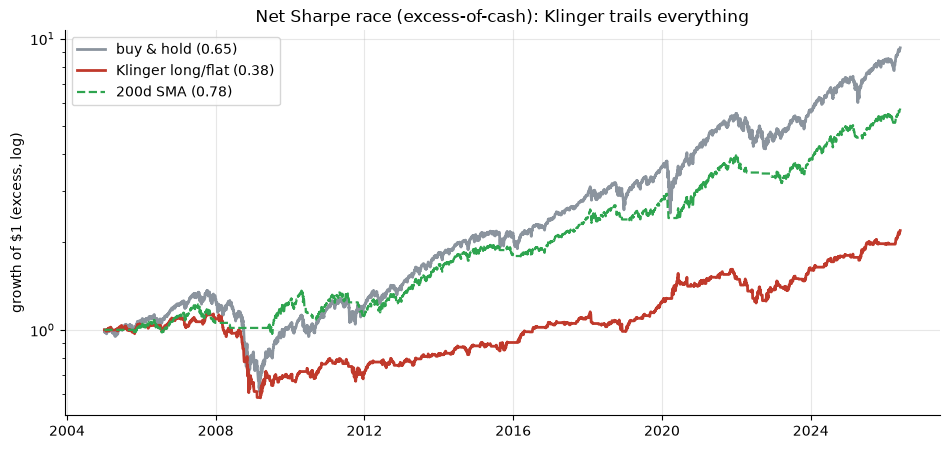

Sharpe  Klinger=0.382  buy-hold=0.645  200dSMA=0.775  MACD=0.548


In [2]:
if HAVE_REAL:
    kpos = st.klinger_position(SPY, mode='zero'); spos = st.sma_position(SPY); mpos = st.macd_position(SPY)
    kb = st.book_returns(SPY, kpos, cost_bps=1.0); sb = st.book_returns(SPY, spos, cost_bps=1.0); mb = st.book_returns(SPY, mpos, cost_bps=1.0)
    eq_hold=(1+kb['asset_excess']).cumprod(); eq_k=(1+kb['strat_excess']).cumprod(); eq_s=(1+sb['strat_excess']).cumprod()
    ks=[st.sharpe(kb['strat_excess'].values), st.sharpe(kb['asset_excess'].values), st.sharpe(sb['strat_excess'].values), st.sharpe(mb['strat_excess'].values)]
    idx=SPY.index
else:
    idx=pd.bdate_range('2005-01-03', periods=R['n_days'])
    eq_hold=pd.Series(np.linspace(1,np.exp(R['hold_cagr']*R['years']),R['n_days']),index=idx)
    eq_k=pd.Series(np.linspace(1,np.exp(R['k_cagr']*R['years']),R['n_days']),index=idx)
    eq_s=pd.Series(np.linspace(1,np.exp(R['sma_cagr']*R['years']),R['n_days']),index=idx)
    ks=[R['k_sharpe'],R['hold_sharpe'],R['sma_sharpe'],R['macd_sharpe']]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(idx, eq_hold, c=GREY, lw=2, label=f'buy & hold ({ks[1]:.2f})')
ax.plot(idx, eq_k, c=RED, lw=2, label=f'Klinger long/flat ({ks[0]:.2f})')
ax.plot(idx, eq_s, c=GREEN, lw=1.6, ls='--', label=f'200d SMA ({ks[2]:.2f})')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess, log)')
ax.set_title('Net Sharpe race (excess-of-cash): Klinger trails everything'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe  Klinger={ks[0]:.3f}  buy-hold={ks[1]:.3f}  200dSMA={ks[2]:.3f}  MACD={ks[3]:.3f}')

> 💡 In plain words: every alternative beats Klinger. Klinger **0.38** < MACD **0.55** < buy-hold **0.65** < the dumbest rule of all, a 200-day average **0.78**. The fancier the volume math, the worse it did.

### 4b · The decisive test — HAC *t* of the daily difference

Is Klinger's underperformance vs buy-and-hold *significant*? The Newey-West *t* of the daily (Klinger − buy-hold) excess-return difference. A *t* below −2 means it is reliably **worse**, not merely unlucky.

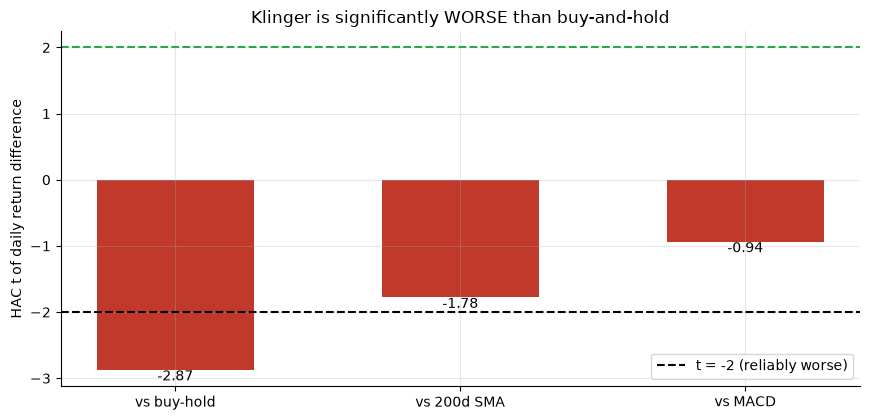

HAC t  vs buy-hold: -2.87  vs SMA: -1.78  vs MACD: -0.94


In [3]:
if HAVE_REAL:
    d_hold = kb['strat_excess'].values - kb['asset_excess'].values
    d_sma  = kb['strat_excess'].values - sb['strat_excess'].values
    d_macd = kb['strat_excess'].values - mb['strat_excess'].values
    tt = [st.hac_t(d_hold), st.hac_t(d_sma), st.hac_t(d_macd)]
else:
    tt = [R['t_vs_hold'], R['t_vs_sma'], R['t_vs_macd']]
labels = ['vs buy-hold','vs 200d SMA','vs MACD']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = [RED if t<0 else GREEN for t in tt]
ax.bar(labels, tt, color=cols, width=.55)
ax.axhline(-2, ls='--', c='k', label='t = -2 (reliably worse)')
ax.axhline(2, ls='--', c=GREEN)
for i,t in enumerate(tt): ax.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
ax.set_ylabel('HAC t of daily return difference'); ax.set_title('Klinger is significantly WORSE than buy-and-hold'); ax.legend()
plt.tight_layout(); plt.show()
print('HAC t  vs buy-hold:', round(tt[0],2), ' vs SMA:', round(tt[1],2), ' vs MACD:', round(tt[2],2))

> 💡 In plain words: the (Klinger − buy-hold) difference has HAC *t* = **-2.87** — past the −2 bar, so the underperformance is *real*, not noise. The desk's `t ≥ 2` bar for a **positive** signal is nowhere in sight; if anything the rule clears the bar on the **wrong side**.

### 4c · The luck test — does a coin beat Klinger's timing?

Block-shuffle the held-position series (21-day blocks keep the persistence and the time-in-market) into 3,000 random schedules; each one is re-booked net of the same costs. Where does Klinger's actual Sharpe fall?

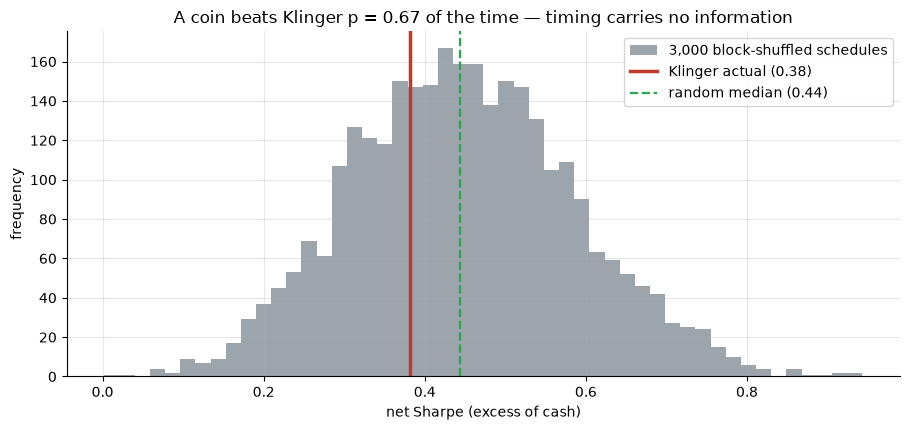

obs 0.382  random-median 0.444  p(random>=obs) = 0.669


In [4]:
if HAVE_REAL:
    pl = st.block_permutation_p(kb, n_draws=3000, seed=430)
    draws=pl['draws']; obs=pl['obs_sharpe']; pval=pl['p_value']
else:
    rng=np.random.default_rng(430); draws=rng.normal(R['placebo_median'],0.18,3000); obs=R['k_sharpe']; pval=R['placebo_p']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='3,000 block-shuffled schedules')
ax.axvline(obs, c=RED, lw=2.5, label=f'Klinger actual ({obs:.2f})')
ax.axvline(np.median(draws), c=GREEN, lw=1.6, ls='--', label=f'random median ({np.median(draws):.2f})')
ax.set_xlabel('net Sharpe (excess of cash)'); ax.set_ylabel('frequency')
ax.set_title(f'A coin beats Klinger p = {pval:.2f} of the time — timing carries no information'); ax.legend()
plt.tight_layout(); plt.show()
print(f'obs {obs:.3f}  random-median {np.median(draws):.3f}  p(random>=obs) = {pval:.3f}')

> 💡 In plain words: the placebo *p* = **0.67** — the random cloud's **median** (0.44) is *above* Klinger (0.38). When the oscillator chooses to be long is no better than (slightly worse than) flipping a coin with the same time-in-market. This is the cleanest statement of "no leading information."

### 4d · Variants & costs — nothing rescues it

Left: the four rule variants (signal-line crossing, long/short) — all *worse*. Right: the cost sweep — Klinger never reaches the buy-and-hold line even at zero cost.

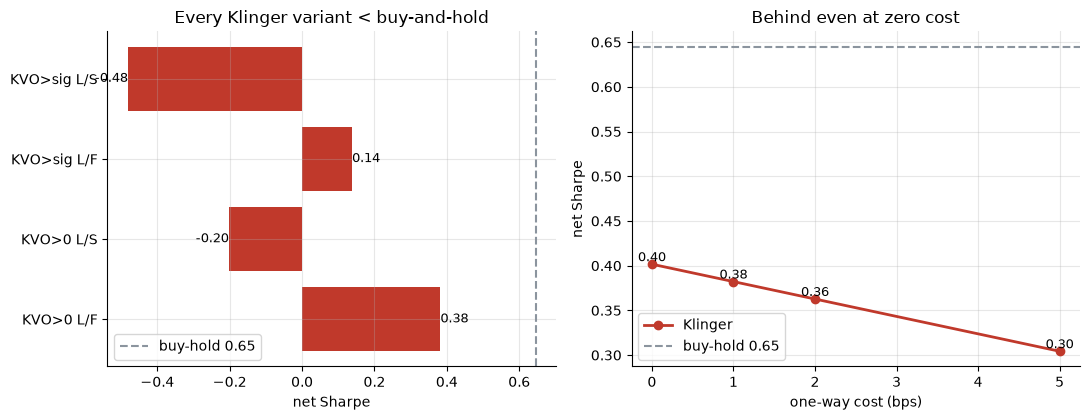

variants: [('KVO>0 L/F', 0.382), ('KVO>0 L/S', -0.203), ('KVO>sig L/F', 0.138), ('KVO>sig L/S', -0.481)]
cost sweep: {0.0: 0.402, 1.0: 0.382, 2.0: 0.363, 5.0: 0.304}


In [5]:
if HAVE_REAL:
    var = []
    for mode, ls, name in [('zero',False,'KVO>0 L/F'),('zero',True,'KVO>0 L/S'),('signal',False,'KVO>sig L/F'),('signal',True,'KVO>sig L/S')]:
        rr = st.run_experiment(SPY, mode=mode, long_short=ls, cost_bps=1.0, with_placebo=False)
        var.append((name, rr['klinger']['sharpe']))
    cb=[c[0] for c in R['costs']]; shp=[st.run_experiment(SPY, mode='zero', cost_bps=c, with_placebo=False)['klinger']['sharpe'] for c in cb]
else:
    var=[(v[0], v[1]) for v in R['variants']]; cb=[c[0] for c in R['costs']]; shp=[c[1] for c in R['costs']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.3))
names=[v[0] for v in var]; sv=[v[1] for v in var]
a1.barh(names, sv, color=[GREEN if s>R['hold_sharpe'] else RED for s in sv])
a1.axvline(R['hold_sharpe'], c=GREY, ls='--', label=f'buy-hold {R["hold_sharpe"]:.2f}')
for i,s in enumerate(sv): a1.annotate(f'{s:.2f}',(s,i),va='center',ha='left' if s>=0 else 'right',fontsize=9)
a1.set_xlabel('net Sharpe'); a1.set_title('Every Klinger variant < buy-and-hold'); a1.legend()
a2.plot(cb, shp, 'o-', c=RED, lw=2, label='Klinger')
a2.axhline(R['hold_sharpe'], c=GREY, ls='--', label=f'buy-hold {R["hold_sharpe"]:.2f}')
for x,y in zip(cb,shp): a2.annotate(f'{y:.2f}',(x,y),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('one-way cost (bps)'); a2.set_ylabel('net Sharpe'); a2.set_title('Behind even at zero cost'); a2.legend()
plt.tight_layout(); plt.show()
print('variants:', [(n,round(s,3)) for n,s in var]); print('cost sweep:', {c:round(s,3) for c,s in zip(cb,shp)})

> 💡 In plain words: the *signal-line* version (**0.14**) is worse than the zero-cross (**0.38**), and both long/short versions go **negative** (**-0.20**, **-0.48**) — shorting on a negative KVO is actively harmful. And at **zero cost** Klinger is still ~0.40, below buy-hold's 0.65. The killer is the signal, not the friction.

### 4e · The panel — it loses everywhere

Klinger long/flat vs buy-and-hold across a 6-ETF panel. Bars below the dashed line lose to buying and holding.

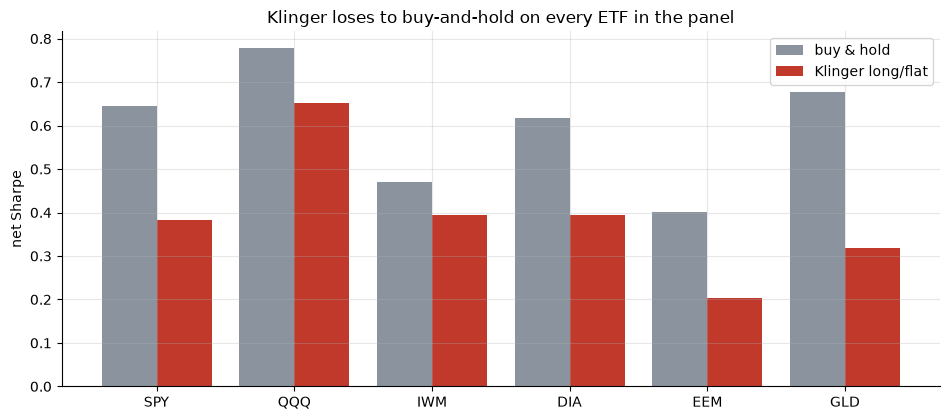

panel (ticker, Klinger, buy-hold): [('SPY', 0.38, 0.65), ('QQQ', 0.65, 0.78), ('IWM', 0.39, 0.47), ('DIA', 0.39, 0.62), ('EEM', 0.2, 0.4), ('GLD', 0.32, 0.68)]


In [6]:
if HAVE_REAL:
    pan = []
    for t,_,_,_ in R['panel']:
        if data.have_real(t):
            bb = data.load_real(t); bb=bb[bb.index<=ASOF]
            rr = st.run_experiment(bb, mode='zero', cost_bps=1.0, with_placebo=False)
            pan.append((t, rr['klinger']['sharpe'], rr['asset_sharpe']))
        else:
            row=[p for p in R['panel'] if p[0]==t][0]; pan.append((t,row[1],row[2]))
else:
    pan=[(p[0],p[1],p[2]) for p in R['panel']]
x=np.arange(len(pan)); kk=[p[1] for p in pan]; hh=[p[2] for p in pan]
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.2,[p[2] for p in pan],.4,color=GREY,label='buy & hold')
ax.bar(x+.2,[p[1] for p in pan],.4,color=RED,label='Klinger long/flat')
ax.set_xticks(x); ax.set_xticklabels([p[0] for p in pan]); ax.set_ylabel('net Sharpe')
ax.set_title('Klinger loses to buy-and-hold on every ETF in the panel'); ax.legend()
plt.tight_layout(); plt.show()
print('panel (ticker, Klinger, buy-hold):', [(p[0],round(p[1],2),round(p[2],2)) for p in pan])

> 💡 In plain words: SPY, QQQ, IWM, DIA, EEM, GLD — Klinger is **below** buy-and-hold on all six. A real leading signal would win *somewhere*; this loses everywhere, which is what a non-signal looks like.

### 4f · Faithful-engine & power control — we know the truth here

On a deterministic synthetic panel where volume **genuinely leads price** by a day (knob `edge`): with `edge=0` the Klinger rule must NOT beat buy-and-hold (no false positive); with a large planted `edge` it must light up. Both hold — so the dead real-tape result is a true negative, not a broken harness.

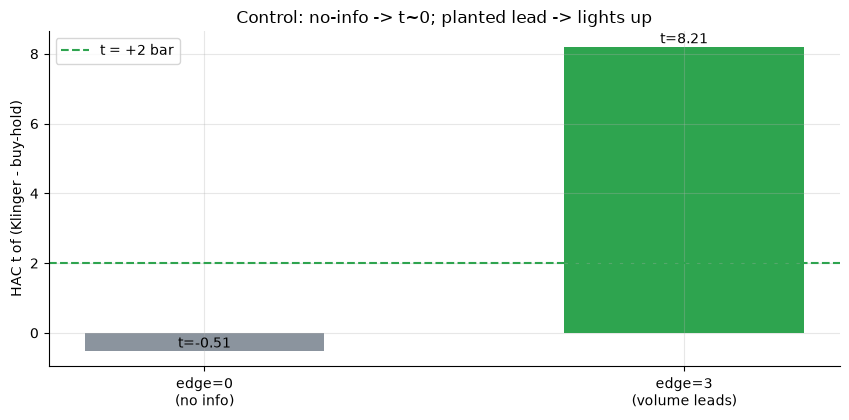

edge=0.0: Klinger=-0.63 hold=-0.36 t_vs_hold=-0.51 placebo_p=0.981
edge=3.0: Klinger=+5.61 hold=+0.44 t_vs_hold=+8.21 placebo_p=0.000


In [7]:
res = []
for edge in (0.0, 3.0):
    bars, truth = data.synthetic_panel(edge=edge, seed=430)
    rr = st.run_experiment(bars, mode='zero', cost_bps=1.0, with_placebo=True, n_draws=2000)
    res.append((edge, rr['klinger']['sharpe'], rr['asset_sharpe'], rr['t_vs_hold'], rr['placebo_p']))
labels=[f'edge={e:.0f}\n(volume leads)' if e>0 else f'edge={e:.0f}\n(no info)' for e,_,_,_,_ in res]
tv=[r[3] for r in res]
fig, ax = plt.subplots(figsize=(8.6,4.3))
ax.bar(labels, tv, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREEN, label='t = +2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t of (Klinger - buy-hold)'); ax.set_title('Control: no-info -> t~0; planted lead -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,h,t,p in res: print(f'edge={e:.1f}: Klinger={k:+.2f} hold={h:+.2f} t_vs_hold={t:+.2f} placebo_p={p:.3f}')

> 💡 In plain words: with **no** planted lead the rule sits at *t* = **-0.51** vs buy-hold (placebo *p* = 0.98 — no false positive); with a **strong** planted lead it explodes to *t* = **8.21** (placebo *p* = 0.00). The engine *can* detect volume-leads-price when it's really there — and on the real SPY tape, it isn't.

## 5 · The verdict

- **Signal `NONE`** — Klinger long/flat net Sharpe **0.38** vs buy-and-hold **0.65**; HAC *t* of the daily difference = **-2.87** (reliably *worse*). No variant clears buy-and-hold; the long/short legs go negative. Nowhere near the desk's *t ≥ 2* bar for a positive edge.
- **Tradability `MIRAGE`** — loses at every cost level (~22 round-trips/yr) and is beaten by a one-line 200d SMA (**0.78**). There is no residual edge to deploy.
- **Volume leads price? `BUSTED`** — a block-shuffled random schedule with the same time-in-market beats Klinger's timing **p = 0.67** of the time. The oscillator is a lagging moving-average of volume; it does not anticipate the index.

## 6 · Could you trade it? — no, and here's the one picture

The drawdown story is the only place Klinger looks defensible — sitting in cash trims the worst losses. But it buys that with so much forgone upside that the **risk-adjusted** return still loses. Net Sharpe vs max drawdown for the three rules:

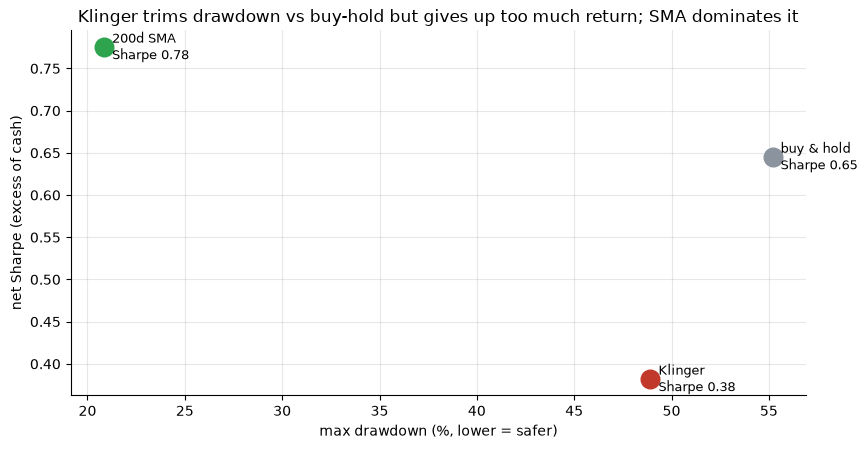

(Sharpe, maxDD): [('buy & hold', 0.65, -0.55), ('Klinger', 0.38, -0.49), ('200d SMA', 0.78, -0.21)]


In [8]:
if HAVE_REAL:
    pts = [('buy & hold', R['hold_sharpe'], st.max_drawdown(kb['asset_excess'].values), GREY),
           ('Klinger', st.sharpe(kb['strat_excess'].values), st.max_drawdown(kb['strat_excess'].values), RED),
           ('200d SMA', st.sharpe(sb['strat_excess'].values), st.max_drawdown(sb['strat_excess'].values), GREEN)]
else:
    pts = [('buy & hold', R['hold_sharpe'], R['hold_mdd'], GREY),
           ('Klinger', R['k_sharpe'], R['k_mdd'], RED),
           ('200d SMA', R['sma_sharpe'], R['sma_mdd'], GREEN)]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
for name, s, dd, c in pts:
    ax.scatter(abs(dd)*100, s, s=180, color=c, zorder=3)
    ax.annotate(f'  {name}\n  Sharpe {s:.2f}', (abs(dd)*100, s), fontsize=9, va='center')
ax.set_xlabel('max drawdown (%, lower = safer)'); ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('Klinger trims drawdown vs buy-hold but gives up too much return; SMA dominates it')
plt.tight_layout(); plt.show()
print('(Sharpe, maxDD):', [(n, round(s,2), round(dd,2)) for n,s,dd,_ in pts])

> 💡 In plain words: yes, Klinger's drawdown (**-49%**) beats buy-and-hold's (**-55%**) — but the 200d SMA gets a far better drawdown (**-21%**) *and* a higher Sharpe, for a fraction of the trading. On every axis a trader cares about, Klinger is dominated. **MIRAGE.**

## 7 · Going further

- **Parameter search is a trap.** You could grid-search KVO spans until something beats buy-and-hold in-sample — but that's curve-fitting (see the desk's data-mining demos). The *standard* (34,55,13) is the honest test, and it fails.
- **Volume as a feature, not a filter.** Volume may still help *conditionally* (e.g. confirming breakouts), but as a standalone leading timing switch on the index it adds nothing here.
- **Why lagging averages can't lead.** KVO is a difference of EMAs of a volume series — a low-pass filter. Filters delay; they don't anticipate. The "leads price" claim is a category error.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*